<a href="https://colab.research.google.com/github/ibrahimelkhalilmehimda/Machine-Learning-projects/blob/main/ASD_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

In [45]:
data = pd.read_csv('/content/train (4).csv')

In [3]:
data.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [103]:
int(data.loc[0,'relation'])

1

In [4]:
data.shape

(800, 22)

In [5]:
data.describe()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.0000,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,28.452118,8.537303,0.201250
std,231.0844,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.310966,4.807676,0.401185
min,1.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.718550,-6.137748,0.000000
25%,200.7500,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.198153,5.306575,0.000000
50%,400.5000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.848350,9.605299,0.000000
75%,600.2500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.865429,12.514484,0.000000
max,800.0000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.461718,15.853126,1.000000


In [7]:
data.groupby('Class/ASD').count()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation
Class/ASD,,,,,,,,,,,,,,,,,,,,,
0,639,639,639,639,639,639,639,639,639,639,...,639,639,639,639,639,639,639,639,639,639
1,161,161,161,161,161,161,161,161,161,161,...,161,161,161,161,161,161,161,161,161,161


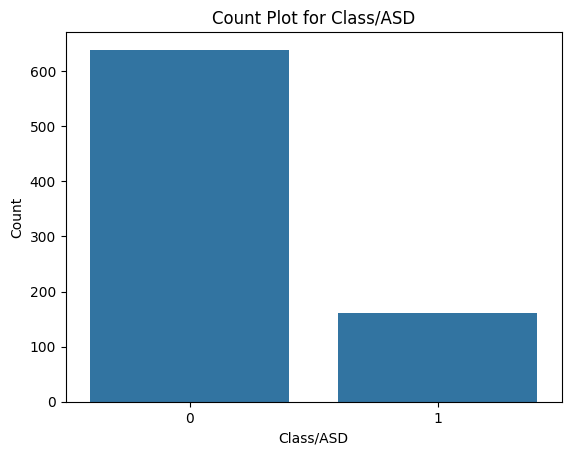

In [33]:
sns.countplot(x=data["Class/ASD"])
plt.title("Count Plot for Class/ASD")
plt.xlabel("Class/ASD")
plt.ylabel("Count")
plt.show()

In [8]:
data['Class/ASD'].value_counts()

,count
Class/ASD,
0,639
1,161


In [13]:
data['Class/ASD'].dtype

dtype('int64')

In [22]:
data.loc[(data['Class/ASD']==1) &  (data['A5_Score']) <1 , ['A7_Score','A4_Score' ] ]

,A7_Score,A4_Score
0,1,0
1,0,0
3,0,0
4,0,0
5,0,0
...,...,...
795,0,0
796,0,0
797,0,0
798,0,0


In [27]:
int(data.loc[2,'Class/ASD'])

1

In [28]:
data.iloc[0:2, 2]

,A2_Score
0,0
1,0


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [31]:
data.isnull().sum()

,0
ID,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0


In [36]:
(data.groupby(data['relation']).count()).loc[:,'Class/ASD']


,Class/ASD
relation,
?,40
Health care professional,2
Others,2
Parent,29
Relative,18
Self,709


In [47]:
mapping = {
     "?": "Others",
     "Relative": "Others",
     "Parent": "Others",
     "Health care professional": "Others"

}

data['relation'] = data['relation'].replace(mapping)
data['relation'].unique()
data['relation'].value_counts()

,count
relation,
Self,709
Others,91


In [49]:
col = list(data.columns)
print(col)

['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD']


In [57]:
for c in col :
  print(c)
  print(data[c].value_counts())

ID
ID
784    1
783    1
782    1
781    1
780    1
      ..
5      1
4      1
3      1
2      1
1      1
Name: count, Length: 800, dtype: int64
A1_Score
A1_Score
1    448
0    352
Name: count, dtype: int64
A2_Score
A2_Score
1    424
0    376
Name: count, dtype: int64
A3_Score
A3_Score
0    440
1    360
Name: count, dtype: int64
A4_Score
A4_Score
0    468
1    332
Name: count, dtype: int64
A5_Score
A5_Score
0    484
1    316
Name: count, dtype: int64
A6_Score
A6_Score
0    557
1    243
Name: count, dtype: int64
A7_Score
A7_Score
0    482
1    318
Name: count, dtype: int64
A8_Score
A8_Score
1    407
0    393
Name: count, dtype: int64
A9_Score
A9_Score
0    404
1    396
Name: count, dtype: int64
A10_Score
A10_Score
1    494
0    306
Name: count, dtype: int64
age
age
25.531166    1
21.541556    1
19.413085    1
23.512162    1
5.935375     1
            ..
43.205790    1
23.561927    1
7.380373     1
47.750517    1
38.172746    1
Name: count, Length: 800, dtype: int64
gender
gender
m    530

# encoding the categorical data

In [60]:
data.columns

Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')

In [65]:
categorical_columns  = [c for c in data.columns if (data[c].dtype == 'O') ]
print(categorical_columns)

['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'age_desc', 'relation']


In [66]:
for col in categorical_columns :
  encoder = LabelEncoder()
  data[col] = encoder.fit_transform(data[col])

In [67]:
data['gender']

,gender
0,0
1,1
2,1
3,0
4,1
...,...
795,1
796,1
797,1
798,0


#SMOTE

In [71]:
x= data.drop(columns=['ID','Class/ASD', 'age'])
y= data['Class/ASD']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)


In [72]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((640, 19), (160, 19), (640,), (160,))

In [73]:
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)
print(x_train_smote.shape)

(1022, 19)


In [75]:
y_train_smote.value_counts()

,count
Class/ASD,
0,511
1,511


# pick up the  model which fit the data well

In [76]:
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
xgboost_classifier = XGBClassifier(random_state=42)

In [77]:
param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20, 30, 50, 70],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}


param_grid_rf = {
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}


param_grid_xgb = {
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.1, 0.2, 0.3],
    "subsample": [0.5, 0.7, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0]
}

In [78]:
random_search_dt = RandomizedSearchCV(estimator=decision_tree, param_distributions=param_grid_dt, n_iter=20, cv=5, scoring="accuracy", random_state=42)
random_search_rf = RandomizedSearchCV(estimator=random_forest, param_distributions=param_grid_rf, n_iter=20, cv=5, scoring="accuracy", random_state=42)
random_search_xgb = RandomizedSearchCV(estimator=xgboost_classifier, param_distributions=param_grid_xgb, n_iter=20, cv=5, scoring="accuracy", random_state=42)

In [80]:
random_search_dt.fit(x_train_smote, y_train_smote)
random_search_rf.fit(x_train_smote, y_train_smote)
random_search_xgb.fit(x_train_smote, y_train_smote)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'colsample_bytree': [0.5, 0.7, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 500],
                                        'subsample': [0.5, 0.7, 1.0]},
                   random_state=42, scoring='accuracy')

In [81]:
models = [random_search_dt, random_search_rf, random_search_xgb]
for m in models :
  print(m)
  print(m.best_params_)
  print(m.best_score_)


RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=20,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 10, 20, 30, 50, 70],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]},
                   random_state=42, scoring='accuracy')
{'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30, 'criterion': 'entropy'}
0.862104256336681
RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [None, 10, 20, 30],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        

In [84]:
best_model = None
best_score=0
for m in models :
  if (best_score < m.best_score_):
    best_model = m.best_estimator_
    best_score = m.best_score_

In [85]:
print (f'best model is {best_model} of score {best_score}')

best model is RandomForestClassifier(bootstrap=False, max_depth=20, n_estimators=50,
                       random_state=42) of score 0.9217742706838834


#evalute the model

In [86]:
score = cross_val_score(best_model, x_train_smote, y_train_smote, cv=5)
print(score)
print(score.mean())

[0.88780488 0.90243902 0.94117647 0.94117647 0.93627451]
0.9217742706838834


In [91]:
y_pred = best_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.79


# predictive system

In [107]:
input =(1,	0,	1,	0,	1	,0,	1,	0	,1,	1 ,0, 0 ,0, 0, 7 ,0, 6.351166, 0 ,1)
input_as_numpy_array = np.asarray(input)
input_reshaped = input_as_numpy_array.reshape(1,-1)
prediction = best_model.predict(input_reshaped)
print(prediction)
if (prediction[0] == 0):
  print('The Person does not have ASD')
else:
  print('The Person has ASD')

[0]
The Person does not have ASD


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
